
# Decision Tree and Random Forest – Bank Marketing Dataset

This notebook follows the steps from the practicum material.

Objectives:
- Understand Decision Tree classification
- Perform preprocessing
- Evaluate model performance
- Visualize the tree and feature importance
- Compare Decision Tree with Random Forest


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Load Dataset

In [3]:

# Update this path to your dataset location
path = "bank-additional-full.csv"

data = pd.read_csv(path, sep=';')
data.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Preprocessing

In [4]:

# Handle missing values
data.dropna(inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

data.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Feature & Target Split

In [7]:

X = data.drop(columns=['y'])
y = data['y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Train Test Split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


## Train Decision Tree

In [9]:

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9121955167111758
[[10638   330]
 [  755   634]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10968
           1       0.66      0.46      0.54      1389

    accuracy                           0.91     12357
   macro avg       0.80      0.71      0.75     12357
weighted avg       0.90      0.91      0.91     12357



## Visualize Decision Tree

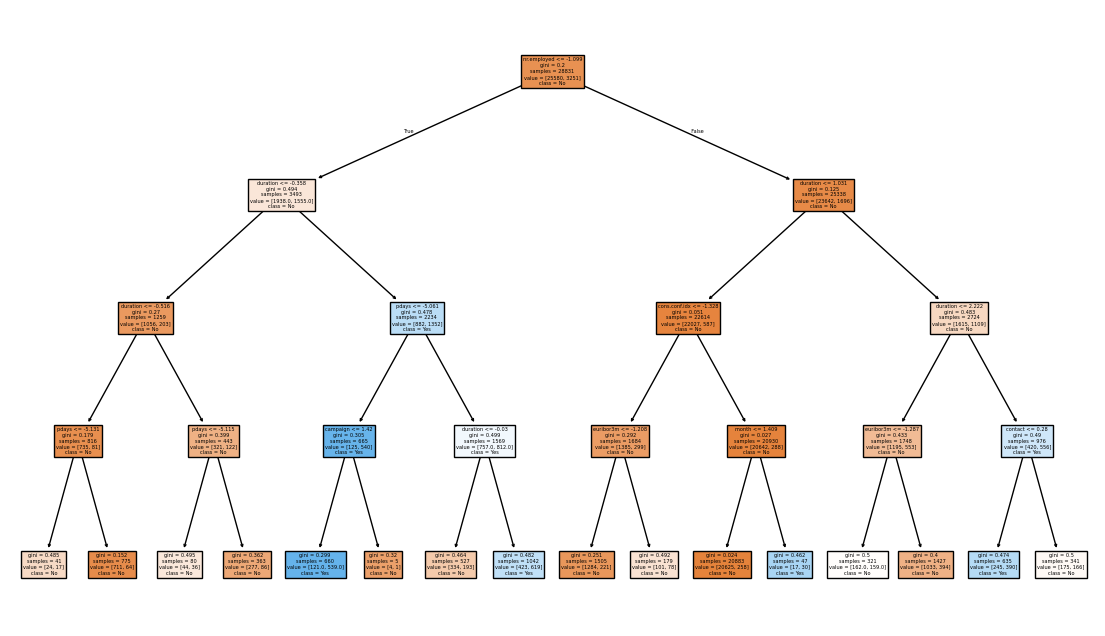

In [10]:

plt.figure(figsize=(14,8))
plot_tree(dt_model, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()


## Feature Importance

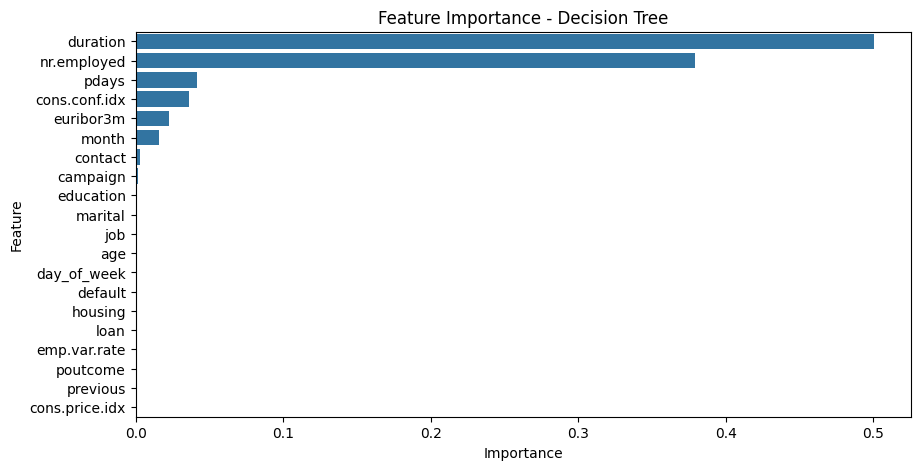

In [11]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree")
plt.show()


## Random Forest Comparison

In [12]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.913814032532168
[[10585   383]
 [  682   707]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     10968
           1       0.65      0.51      0.57      1389

    accuracy                           0.91     12357
   macro avg       0.79      0.74      0.76     12357
weighted avg       0.91      0.91      0.91     12357

